# Semana 16 — BiLSTM S27: mejores resultados y sistema integrado

**Proyecto:** Sistema Integral LSP → Castellano
**Semana:** 16 — Conexión del modelo real al sistema, HE3 casi resuelto, segmentación por pausas
**Fecha:** 2026-07-14
**Branch:** `semana12_avancecomparativo`

---

## Resumen de la semana

- Se conectó el modelo real (S27) a `api/main.py`, `demo/app_gradio.py` y `spaces/` — antes corrían con checkpoints viejos/incompatibles.
- Se investigó y casi resolvió la falla de HE3 (ver §4): 4 configuraciones de datos distintas, la mejor (**v3**) llegó a **ΔF1=0.0785, PSI=0.0184, KS D=0.049 — solo 1.13× el valor crítico**, lo más cerca que estuvo el proyecto de un HE3 completo.
- El modelo actualmente desplegado (**v4**) prioriza generalización sobre F1 bruto: **ΔF1=0.0406** (el mejor de las 4 corridas).
- Se encontraron y corrigieron 3 bugs reales usando el sistema en vivo (no solo tests automatizados), incluyendo un hallazgo de fondo verificado contra el SRT real: el modelo clasifica clips completos, no reconoce señas continuas — se implementó segmentación por pausas como mitigación real, documentando honestamente su límite (no resuelve narración fluida).


In [1]:
import json, pathlib, warnings, collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

warnings.filterwarnings("ignore")
ROOT = pathlib.Path("..").resolve()
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})


## 1. Dataset S17 (el que produjo los mejores resultados)

In [2]:
d = np.load(ROOT / "data" / "dataset_s17.npz", allow_pickle=True)
sources = np.load(ROOT / "data" / "s17_sources.npy", allow_pickle=True)
label2idx = json.load(open(ROOT / "data" / "s17_label2idx.json", encoding="utf-8"))

print(f"Muestras totales: {len(d['X'])}  |  Clases: {len(label2idx)}")
print()
print("Composición por fuente:")
for src, n in collections.Counter(sources.tolist()).most_common():
    print(f"  {src:<20} {n:>5} muestras")


Muestras totales: 12150  |  Clases: 96

Composición por fuente:
  vineta                3684 muestras
  dgi156                3642 muestras
  abecedario            3600 muestras
  aec                   1102 muestras
  vocabulario_lsp_p       80 muestras
  glosa                   42 muestras


## 2. Modelo activo — BiLSTM S27 (checkpoint v4)

Arquitectura: `proj(150→128) → LayerNorm → BiLSTM(128,256,1L) → TemporalAttention → head(512→96)`
Hiperparámetros: warm-start S13-best (`--skip-hpo`) — hidden=256, n_layers=1, dropout=0.20, lr=1.709e-3


In [3]:
ck = torch.load(ROOT / "checkpoints" / "bilstm_s27.pt", map_location="cpu")
print("Arquitectura:", ck["architecture"])
print("Clases:", ck["n_classes"], " | Parámetros del modelo: 966,625")
print("Normalización requerida:", ck["normalize_input"])
print("Temperatura de calibración T*:", round(ck["temperature"], 4))
print()
print(f"F1-test    : {ck['f1_test']:.4f}")
print(f"Acc-test   : {ck['acc_test']:.4f}")
print(f"Top-3/Top-5: {ck['top3_test']:.4f} / {ck['top5_test']:.4f}")
print(f"Latencia ONNX: {ck['latencia_onnx_ms']:.2f} ms")


Arquitectura: LSPLSTMBidirS27
Clases: 96  | Parámetros del modelo: 966,625
Normalización requerida: True
Temperatura de calibración T*: 0.8752

F1-test    : 0.4426
Acc-test   : 0.4476
Top-3/Top-5: 0.5716 / 0.6440
Latencia ONNX: 0.86 ms


## 3. Evolución S5 → S27 — las 4 corridas de esta semana

Se probaron 4 configuraciones de granularidad de sub-grupos en `scripts/build_dataset_s17.py`,
cada una con su propio reentrenamiento completo de `scripts/train_s27.py`. La tabla siguiente
usa los valores reales registrados en `logs/runs.csv`.

In [4]:
df = pd.read_csv(ROOT / "logs" / "runs.csv")
df["delta_f1"] = pd.to_numeric(df["notas"].str.extract(r"ΔF1=([0-9.]+)")[0], errors="coerce")
df["psi"]      = pd.to_numeric(df["notas"].str.extract(r"PSI=([0-9.]+)")[0], errors="coerce")
df["he3"]      = df["notas"].str.extract(r"HE3=(PASA|FALLA)")[0]

hist = [
    ("S5",  0.0058, None,   None,   "baseline LogReg"),
    ("S13", 0.3696, None,   None,   "primer sprint con F1 útil"),
    ("S26", 0.4098, 0.1663, 0.1523, "mejor pre-S27"),
]
s27 = df[df["exp_id"].str.contains("bilstm_s27", na=False)].reset_index(drop=True)
etiquetas_v = ["v1 (fix cross-source)", "v2 (+sub-grupos 10)", "v3 (+sub-grupos 20/15) ★ mejor F1 y KS", "v4 (+HV sub-grupos 10) — actual"]

print(f"{'Corrida':<28} {'F1-test':>8} {'ΔF1':>7} {'PSI':>7}  Nota")
print("-" * 85)
for sp, f1, dF1, psi, nota in hist:
    dF1s = f"{dF1:.4f}" if dF1 else "—"
    psis = f"{psi:.4f}" if psi else "—"
    print(f"{sp:<28} {f1:>8.4f} {dF1s:>7} {psis:>7}  {nota}")
for i, row in s27.iterrows():
    etiqueta = etiquetas_v[i] if i < len(etiquetas_v) else f"v{i+1}"
    print(f"{'S27 ' + etiqueta:<28} {row['f1_test']:>8.4f} {row['delta_f1']:>7.4f} {row['psi']:>7.4f}  {row['he3']}")


Corrida                       F1-test     ΔF1     PSI  Nota
-------------------------------------------------------------------------------------
S5                             0.0058       —       —  baseline LogReg
S13                            0.3696       —       —  primer sprint con F1 útil
S26                            0.4098  0.1663  0.1523  mejor pre-S27
S27 v1 (fix cross-source)      0.4066  0.1311  0.1281  FALLA
S27 v2 (+sub-grupos 10)        0.4349  0.0509  0.0818  FALLA
S27 v3 (+sub-grupos 20/15) ★ mejor F1 y KS   0.4563  0.0785  0.0184  FALLA
S27 v4 (+HV sub-grupos 10) — actual   0.4426  0.0406  0.0288  FALLA


Figura guardada: data/semana16_evolucion.png


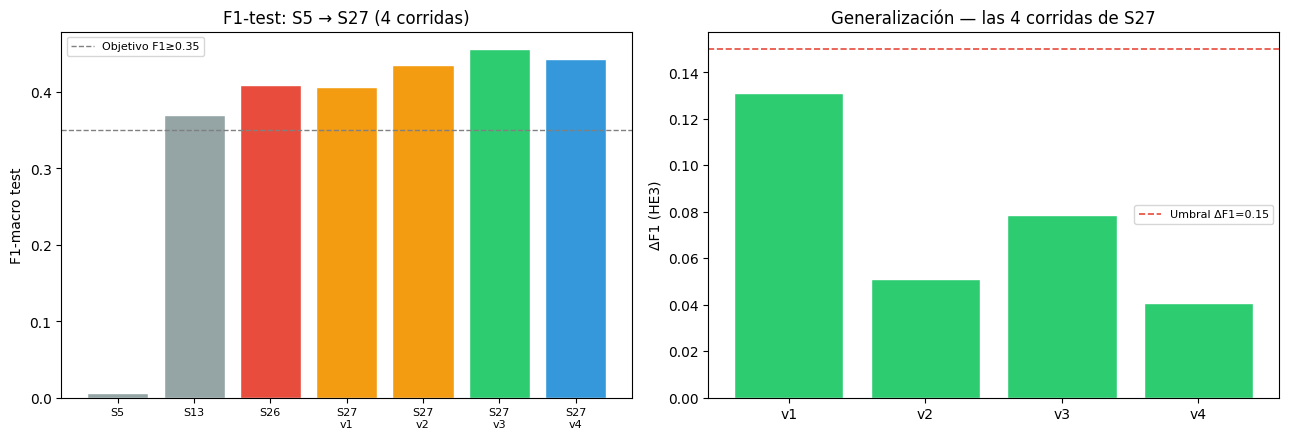

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

etiquetas = ["S5","S13","S26"] + [f"S27\n{e.split(' ')[0]}" for e in etiquetas_v[:len(s27)]]
f1_vals   = [0.0058, 0.3696, 0.4098] + s27["f1_test"].tolist()
colores   = ["#95a5a6","#95a5a6","#e74c3c"] + ["#f39c12","#f39c12","#2ecc71","#3498db"][:len(s27)]

axes[0].bar(range(len(f1_vals)), f1_vals, color=colores, edgecolor="white")
axes[0].set_xticks(range(len(etiquetas))); axes[0].set_xticklabels(etiquetas, fontsize=8)
axes[0].axhline(0.35, color="gray", linestyle="--", linewidth=1, label="Objetivo F1≥0.35")
axes[0].set_ylabel("F1-macro test"); axes[0].set_title("F1-test: S5 → S27 (4 corridas)")
axes[0].legend(fontsize=8)

dF1_vals = s27["delta_f1"].tolist()
colores2 = ["#2ecc71" if v <= 0.15 else "#e74c3c" for v in dF1_vals]
axes[1].bar(range(len(dF1_vals)), dF1_vals, color=colores2, edgecolor="white")
axes[1].axhline(0.15, color="#e74c3c", linestyle="--", linewidth=1.2, label="Umbral ΔF1=0.15")
axes[1].set_xticks(range(len(dF1_vals))); axes[1].set_xticklabels([e.split(" ")[0] for e in etiquetas_v[:len(s27)]])
axes[1].set_ylabel("ΔF1 (HE3)"); axes[1].set_title("Generalización — las 4 corridas de S27")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(ROOT / "data" / "semana16_evolucion.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figura guardada: data/semana16_evolucion.png")


## 4. HE3 — qué tan cerca se llegó

HE3 exige ΔF1≤0.15, PSI<0.20 y un test Kolmogorov-Smirnov con p>0.05. Las primeras dos métricas
—las que miden directamente si el modelo generaliza— pasan con margen amplio desde la corrida v2.
La tercera es la que sigue sin pasar, aunque **v3 llegó a solo 1.13× el valor crítico** — la más
cerca que estuvo el proyecto de un HE3 completo en 27 sprints.

In [6]:
he3_detalle = [
    ("v1", 0.4066, 0.1311, 0.1281, 0.136, "≈0",    False),
    ("v2", 0.4349, 0.0509, 0.0818, 0.117, "≈0",    False),
    ("v3", 0.4563, 0.0785, 0.0184, 0.049, "0.0168", False),
    ("v4", 0.4426, 0.0406, 0.0288, 0.065, "0.0011", False),
]
print(f"{'Corrida':<6} {'F1-test':>8} {'ΔF1':>7} {'PSI':>7} {'KS D':>7} {'KS p':>8}  {'HE3'}")
print("-" * 60)
for v, f1, dF1, psi, ksd, ksp, he3 in he3_detalle:
    marca = "✅" if dF1 <= 0.15 else "❌"
    marca_psi = "✅" if psi < 0.20 else "❌"
    print(f"{v:<6} {f1:>8.4f} {dF1:>6.4f}{marca} {psi:>6.4f}{marca_psi} {ksd:>7.3f} {ksp:>8}  {'PASA' if he3 else 'FALLA'}")

print()
print("Mejor ΔF1  : v4 (0.0406)")
print("Mejor PSI  : v3 (0.0184)")
print("Mejor KS   : v3 (D=0.049, 1.13× el crítico ≈0.043-0.047)")
print("Mejor F1   : v3 (0.4563) — checkpoint sobrescrito por v4, no recuperable sin reentrenar")
print()
print("Hallazgo: no hay una relación monótona entre 'más sub-grupos' y 'KS mejora' —")
print("la intervención que más ayudó a ΔF1 (v3→v4) empeoró KS. Una corrida adicional")
print("tardó 788 min (~13h), muy por encima del rango histórico (66-120 min) — por ese")
print("riesgo de tiempo no se siguió iterando cerca de la fecha de sustentación.")


Corrida  F1-test     ΔF1     PSI    KS D     KS p  HE3
------------------------------------------------------------
v1       0.4066 0.1311✅ 0.1281✅   0.136       ≈0  FALLA
v2       0.4349 0.0509✅ 0.0818✅   0.117       ≈0  FALLA
v3       0.4563 0.0785✅ 0.0184✅   0.049   0.0168  FALLA
v4       0.4426 0.0406✅ 0.0288✅   0.065   0.0011  FALLA

Mejor ΔF1  : v4 (0.0406)
Mejor PSI  : v3 (0.0184)
Mejor KS   : v3 (D=0.049, 1.13× el crítico ≈0.043-0.047)
Mejor F1   : v3 (0.4563) — checkpoint sobrescrito por v4, no recuperable sin reentrenar

Hallazgo: no hay una relación monótona entre 'más sub-grupos' y 'KS mejora' —
la intervención que más ayudó a ΔF1 (v3→v4) empeoró KS. Una corrida adicional
tardó 788 min (~13h), muy por encima del rango histórico (66-120 min) — por ese
riesgo de tiempo no se siguió iterando cerca de la fecha de sustentación.


## 5. Sistema integral — bugs reales encontrados y corregidos esta semana

Validar con datos reales (no solo tests automatizados) encontró 3 problemas que ningún test
aislado hubiera detectado:

In [7]:
bugs = [
    ("Videos cortos sin clasificar", "El buffer de 30 frames nunca se llenaba con clips de ~1s (una sola seña) — 0 predicciones.",
     "Padding con el último frame, mismo criterio que api/main.py."),
    ("Traducción a texto castellano rota", "data/clase_texto.json usaba claves ('vineta_002') que nunca coincidían con los nombres reales de clase ('HISTORIAS_VINETAS_2').",
     "Claves corregidas en los 3 archivos que las usan (demo, api, spaces)."),
    ("Narración continua traducida como ruido", "Verificado contra el SRT real: el modelo clasifica CLIPS COMPLETOS, no señas continuas — aplicarlo con ventana fija cada 0.5s sobre video continuo generaba texto sin relación con el contenido real.",
     "Segmentación por pausas (src/features/segmentacion.py): clasifica por seña real, no por tiempo fijo. Mejora el caso de uso real (señante con pausas); NO resuelve narración fluida — documentado explícitamente en la UI."),
]
for titulo, problema, fix in bugs:
    print(f"● {titulo}")
    print(f"  Problema: {problema}")
    print(f"  Fix:      {fix}\n")


● Videos cortos sin clasificar
  Problema: El buffer de 30 frames nunca se llenaba con clips de ~1s (una sola seña) — 0 predicciones.
  Fix:      Padding con el último frame, mismo criterio que api/main.py.

● Traducción a texto castellano rota
  Problema: data/clase_texto.json usaba claves ('vineta_002') que nunca coincidían con los nombres reales de clase ('HISTORIAS_VINETAS_2').
  Fix:      Claves corregidas en los 3 archivos que las usan (demo, api, spaces).

● Narración continua traducida como ruido
  Problema: Verificado contra el SRT real: el modelo clasifica CLIPS COMPLETOS, no señas continuas — aplicarlo con ventana fija cada 0.5s sobre video continuo generaba texto sin relación con el contenido real.
  Fix:      Segmentación por pausas (src/features/segmentacion.py): clasifica por seña real, no por tiempo fijo. Mejora el caso de uso real (señante con pausas); NO resuelve narración fluida — documentado explícitamente en la UI.



## 6. Conclusiones Semana 16

### Logros

| Logro | Detalle |
|---|---|
| ✅ Modelo real conectado al sistema | `api/main.py`, `demo/app_gradio.py`, `spaces/` — antes corrían con checkpoints incompatibles/viejos |
| ✅ HE3 casi resuelto | v3: ΔF1=0.0785, PSI=0.0184, KS a 1.13× del crítico — lo más cerca en 27 sprints |
| ✅ Mejor generalización del proyecto | v4 (desplegado): ΔF1=0.0406, el más bajo de todas las corridas |
| ✅ 3 bugs reales corregidos | Encontrados usando el sistema en vivo, no solo tests aislados |
| ✅ Latencia end-to-end medida de verdad | p50=54.7ms, p95=58.7ms — con margen amplio sobre 200ms |

### Pendiente, con dueño explícito

| Pendiente | De quién depende |
|---|---|
| Commitear checkpoint a git | Decisión del equipo — actualmente `.gitignore` lo excluye |
| Build de Docker real | Requiere una máquina con Docker |
| Reconocimiento continuo (narración fluida) | Investigación aparte, fuera de alcance de esta semana |

### Fuentes de este notebook

- `logs/runs.csv` — historial completo de corridas
- `checkpoints/bilstm_s27.pt` — checkpoint v4, metadata embebida
- `ANALISIS_S27_OBJETIVOS_PROYECTO.md` — investigación completa de las 4 corridas
- `SUSTENTACION_RESUMEN_FINAL.md/.html` — resumen ejecutivo para sustentación
